In [1]:
!pip install bnltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 850.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 131.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.3
    Uninstalling ml_dtypes-0.5.3:
      Successfully uninstalled ml_dtypes-0.5.3
  Attempting uninstall: tensorboard
    Found

In [2]:
from sklearn.model_selection import train_test_split
from bnltk.tokenize import Tokenizers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, make_scorer, roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import nltk
import codecs

In [3]:
INPUT_FILE = "/content/ecommerce_dataset.txt"
STOPWORDS = "/content/stopwords.txt"

In [4]:
counter = collections.Counter()
tokenizers = Tokenizers()


X,y = [],[]

bangla_stopwords = codecs.open(STOPWORDS, 'r', encoding='utf-8').read().split()

input = codecs.open(INPUT_FILE, 'r', encoding='utf-16')

import string
punctuations = set(string.punctuation)

for line in input:
  labels, sent = line.strip().split("\t")
  print("Labels: ", labels)
  print("Original Sent: ",sent)


  #tokenizers
  words = tokenizers.bn_word_tokenizer(sent)
  print("After Tokenizing:", words)

  #remove puns
  remove_puns = [word for word in words if word not in punctuations]
  print("After Removing Punctutions: ", remove_puns)


  #remove stop word
  remove_stopwords = [word for word in remove_puns if word not in bangla_stopwords]
  print("After removing Stopwords: ",remove_stopwords)

  maxlen = 0
  if len(remove_stopwords) > maxlen:
    maxlen = len(remove_stopwords)

  for a in remove_stopwords:
    counter[a]=+1

  y.append(labels)
  X.append(' '.join(remove_stopwords))

Labels:  0
Original Sent:  অনেকগুলা অরডার আছে একটু দেখবেন
After Tokenizing: ['অনেকগুলা', 'অরডার', 'আছে', 'একটু', 'দেখবেন']
After Removing Punctutions:  ['অনেকগুলা', 'অরডার', 'আছে', 'একটু', 'দেখবেন']
After removing Stopwords:  ['অনেকগুলা', 'অরডার', 'একটু', 'দেখবেন']
Labels:  1
Original Sent:  ভালোবাসা রইল ইভ্যালির প্রতি
After Tokenizing: ['ভালোবাসা', 'রইল', 'ইভ্যালির', 'প্রতি']
After Removing Punctutions:  ['ভালোবাসা', 'রইল', 'ইভ্যালির', 'প্রতি']
After removing Stopwords:  ['ভালোবাসা', 'রইল', 'ইভ্যালির']
Labels:  0
Original Sent:  আগের প্রডাক্ট ক্লিয়ার করেন তারাতাড়ি
After Tokenizing: ['আগের', 'প্রডাক্ট', 'ক্লিয়ার', 'করেন', 'তারাতাড়ি']
After Removing Punctutions:  ['আগের', 'প্রডাক্ট', 'ক্লিয়ার', 'করেন', 'তারাতাড়ি']
After removing Stopwords:  ['আগের', 'প্রডাক্ট', 'ক্লিয়ার', 'তারাতাড়ি']
Labels:  0
Original Sent:  আর ভাল লাগতেছে না
After Tokenizing: ['আর', 'ভাল', 'লাগতেছে', 'না']
After Removing Punctutions:  ['আর', 'ভাল', 'লাগতেছে', 'না']
After removing Stopwords:  ['ভাল', 'লাগতেছে', 'না']


In [ ]:
print(len(X))

1631


In [ ]:
print(X[1])
print(y[1])

ভালোবাসা রইল ইভ্যালির
1


In [ ]:
print(type(y))

<class 'list'>


1    862
0    769
Name: count, dtype: int64


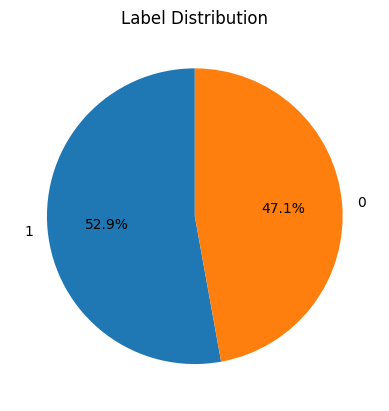

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts =pd.Series(y).value_counts()
print(label_counts)

plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Label Distribution")
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=45, test_size=0.2)
print(len(X_train))

1304


In [6]:

X_train_text = X_train
X_test_text = X_test

vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    use_idf=True,
    tokenizer=lambda x: x.split()
)

# Vectorize
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

print("Train shape:", X_train_vec.shape)
print("Test shape:", X_test_vec.shape)


Train shape: (1304, 15326)
Test shape: (327, 15326)


In [9]:
X_train_vec[0][0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12 stored elements and shape (1, 15326)>

# Models

## LR (L2)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_vec, y_train)
pred_lr = lr.predict(X_test_vec)
print(classification_report(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87       155
           1       0.86      0.92      0.89       172

    accuracy                           0.88       327
   macro avg       0.89      0.88      0.88       327
weighted avg       0.89      0.88      0.88       327

[[130  25]
 [ 13 159]]


In [11]:
from sklearn.linear_model import LogisticRegression
lr_2=LogisticRegression(penalty='l1', solver='liblinear')
lr_2.fit(X_train_vec, y_train)
pred_lr_2 = lr_2.predict(X_test_vec)
print(classification_report(y_test, pred_lr_2))
print(confusion_matrix(y_test, pred_lr_2))

              precision    recall  f1-score   support

           0       0.73      0.84      0.78       155
           1       0.83      0.72      0.77       172

    accuracy                           0.78       327
   macro avg       0.78      0.78      0.78       327
weighted avg       0.78      0.78      0.78       327

[[130  25]
 [ 48 124]]


In [12]:
from sklearn import svm
clf=svm.SVC(kernel='linear')
clf.fit(X_train_vec, y_train)
pred_svm = clf.predict(X_test_vec)
print(classification_report(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


              precision    recall  f1-score   support

           0       0.89      0.86      0.87       155
           1       0.88      0.90      0.89       172

    accuracy                           0.88       327
   macro avg       0.88      0.88      0.88       327
weighted avg       0.88      0.88      0.88       327

[[133  22]
 [ 17 155]]


In [13]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rf_classifier.fit(X_train_vec, y_train)
pred_rf = rf_classifier.predict(X_test_vec)
print(classification_report(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81       155
           1       0.79      0.93      0.86       172

    accuracy                           0.83       327
   macro avg       0.85      0.83      0.83       327
weighted avg       0.85      0.83      0.83       327

[[113  42]
 [ 12 160]]


In [14]:
from sklearn.linear_model import SGDClassifier
sgd_classifier=SGDClassifier(loss = 'log_loss', penalty='l2', max_iter=10, random_state=0)
sgd_classifier.fit(X_train_vec, y_train)
pred_sgd = sgd_classifier.predict(X_test_vec)
print(classification_report(y_test, pred_sgd))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       155
           1       0.87      0.89      0.88       172

    accuracy                           0.87       327
   macro avg       0.87      0.87      0.87       327
weighted avg       0.87      0.87      0.87       327



In [16]:
input = X_test_vec[0]

output = sgd_classifier.predict(input)
print(output)

['0']


In [17]:
input = X_test_vec[0]

output = lr_2.predict(input)
print(output)

['0']


In [18]:
input = X_test_vec[0]

output = rf_classifier.predict(input)
print(output)

['0']


In [19]:
input = X_test_vec[10]

output = sgd_classifier.predict(input)
print(output)

['1']


In [20]:
input = X_test_vec[10]

output = rf_classifier.predict(input)
print(output)

['1']
